In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.insert(0, "../../../src")
from config.data_config import HEADER_MAPPING, PAS_PARAM_DISPLAY
from visualization.plotting_functions.scatter_plot import scatter_plot

# from visualization.plotting_functions.boxplot import plot_monthly_boxplots


In [2]:
def load_colocation_data(metadata_file):
    with open(metadata_file, "r") as f:
        metadata = json.load(f)
    return metadata


def load_site_data(aqms_filepath, pas_filepaths):
    """
    Load AQMS and PAS data from the specified file paths.

    Args:
        aqms_filepath (str): Path to the AQMS data file.
        pas_filepaths (dict): Dictionary of PAS file paths with sensor IDs as keys.

    Returns:
        pd.DataFrame, dict: AQMS data and dictionary of PAS data.
    """
    # Load AQMS data
    aqms_data = pd.read_csv(aqms_filepath, index_col=0, parse_dates=True)

    # Load PAS data into a dictionary
    pas_data = {}
    for sensor_id, filepath in pas_filepaths.items():
        pas_data[sensor_id] = pd.read_csv(filepath, index_col=0, parse_dates=True)

    return aqms_data, pas_data


def prepare_scatter_plot_data(aqms_data, pas_data_dict, parameter, header_mapping):
    """
    Prepare data for scatter plotting by combining AQMS and multiple PAS data for a specific parameter.

    Args:
        aqms_data (pd.DataFrame): AQMS data.
        pas_data_dict (dict): Dictionary of PAS data with sensor codes as keys.
        parameter (str): Parameter to prepare for plotting.
        header_mapping (dict): Mapping of AQMS parameters to PAS parameters.

    Returns:
        list: List of tuples containing x and y data for scatter plots.
    """
    scatter_plot_data = []

    # Normalize datetime format in AQMS data
    aqms_data.index = pd.to_datetime(aqms_data.index, utc=True)
    # aqms_data_resampled = aqms_data.resample(freq).mean()

    if parameter in header_mapping:
        pas_params = header_mapping[parameter]

        for pas_param in pas_params:
            if parameter in aqms_data.columns:
                x = aqms_data[parameter].dropna()

                for sensor_id, pas_df in pas_data_dict.items():
                    pas_df.index = pd.to_datetime(pas_df.index, utc=True)
                    # pas_df_resampled = pas_df.resample(freq).mean()

                    if pas_param in pas_df.columns:
                        y = pas_df[pas_param].dropna()

                        # Match the common datetime_utc values
                        common_index = x.index.intersection(y.index)
                        x_matched = x.loc[common_index]
                        y_matched = y.loc[common_index]

                        scatter_plot_data.append(
                            (
                                x_matched,
                                y_matched,
                                (parameter, pas_param),
                                sensor_id,
                                # f"{parameter} vs {pas_param} for {sensor_id}",
                            )
                        )

    return scatter_plot_data


Site:  Armidale
scatter plot data:  [(datetime_utc
2019-04-02 00:00:00+00:00    85.969833
2019-04-04 00:00:00+00:00    72.659042
2019-05-10 00:00:00+00:00    69.428250
2019-05-11 00:00:00+00:00    84.819917
2019-05-12 00:00:00+00:00    74.729500
                               ...    
2024-05-25 00:00:00+00:00    83.254708
2024-05-26 00:00:00+00:00    76.507542
2024-05-27 00:00:00+00:00    76.430750
2024-05-28 00:00:00+00:00    78.207292
2024-05-29 00:00:00+00:00    70.504042
Name: HUMID, Length: 1832, dtype: float64, datetime_utc
2019-04-02 00:00:00+00:00    24.492
2019-04-04 00:00:00+00:00    26.853
2019-05-10 00:00:00+00:00    28.886
2019-05-11 00:00:00+00:00    28.156
2019-05-12 00:00:00+00:00    29.686
                              ...  
2024-05-25 00:00:00+00:00    71.266
2024-05-26 00:00:00+00:00    64.008
2024-05-27 00:00:00+00:00    65.300
2024-05-28 00:00:00+00:00    63.527
2024-05-29 00:00:00+00:00    57.837
Name: humidity, Length: 1832, dtype: float64, ('HUMID', 'humidity'),

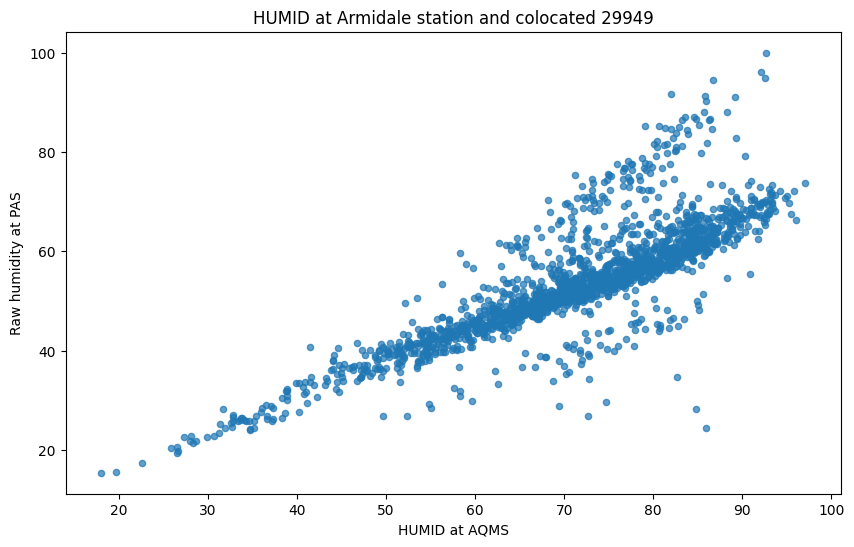

scatter plot data:  [(datetime_utc
2019-04-02 00:00:00+00:00    13.291625
2019-04-04 00:00:00+00:00    14.532833
2019-05-10 00:00:00+00:00     9.013167
2019-05-11 00:00:00+00:00     4.522917
2019-05-12 00:00:00+00:00     9.938583
                               ...    
2024-05-25 00:00:00+00:00     9.920625
2024-05-26 00:00:00+00:00     9.803625
2024-05-27 00:00:00+00:00     8.926667
2024-05-28 00:00:00+00:00     8.402958
2024-05-29 00:00:00+00:00     8.250833
Name: TEMP, Length: 1832, dtype: float64, datetime_utc
2019-04-02 00:00:00+00:00    21.9
2019-04-04 00:00:00+00:00    22.2
2019-05-10 00:00:00+00:00    25.0
2019-05-11 00:00:00+00:00    24.5
2019-05-12 00:00:00+00:00    24.5
                             ... 
2024-05-25 00:00:00+00:00    14.4
2024-05-26 00:00:00+00:00    14.0
2024-05-27 00:00:00+00:00    12.9
2024-05-28 00:00:00+00:00    13.1
2024-05-29 00:00:00+00:00    12.5
Name: temperature, Length: 1832, dtype: float64, ('TEMP', 'temperature'), '29949')]
X datetime_utc
2019-04-

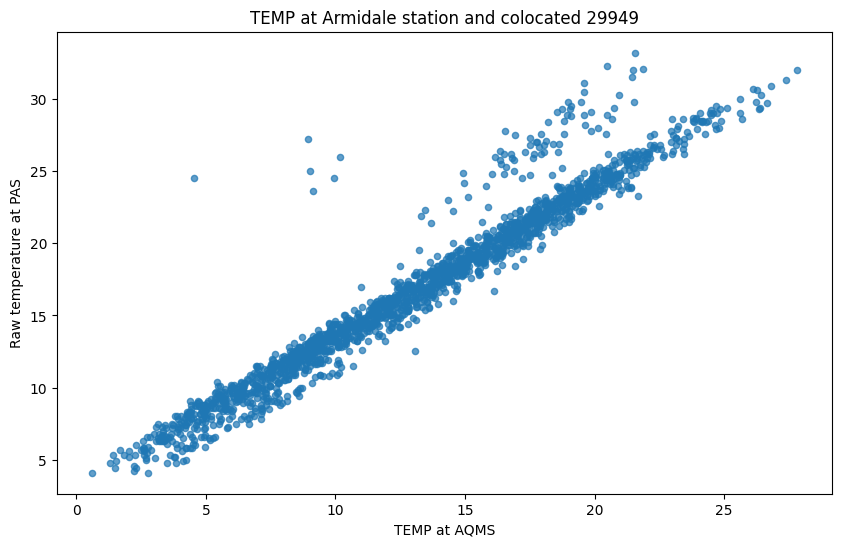

scatter plot data:  [(datetime_utc
2019-04-02 00:00:00+00:00     2.279667
2019-04-04 00:00:00+00:00     0.985000
2019-05-10 00:00:00+00:00     4.367200
2019-05-11 00:00:00+00:00    16.948917
2019-05-12 00:00:00+00:00    25.412429
                               ...    
2024-05-25 00:00:00+00:00     9.762208
2024-05-26 00:00:00+00:00    12.270478
2024-05-27 00:00:00+00:00    16.400000
2024-05-28 00:00:00+00:00    18.419667
2024-05-29 00:00:00+00:00    23.034565
Name: PM2.5, Length: 1831, dtype: float64, datetime_utc
2019-04-02 00:00:00+00:00    11.6
2019-04-04 00:00:00+00:00    17.9
2019-05-10 00:00:00+00:00     1.3
2019-05-11 00:00:00+00:00     2.0
2019-05-12 00:00:00+00:00     3.3
                             ... 
2024-05-25 00:00:00+00:00     7.8
2024-05-26 00:00:00+00:00     9.2
2024-05-27 00:00:00+00:00    12.3
2024-05-28 00:00:00+00:00    15.7
2024-05-29 00:00:00+00:00    17.7
Name: pm2.5_alt, Length: 1831, dtype: float64, ('PM2.5', 'pm2.5_alt'), '29949'), (datetime_utc
2019-04-02 

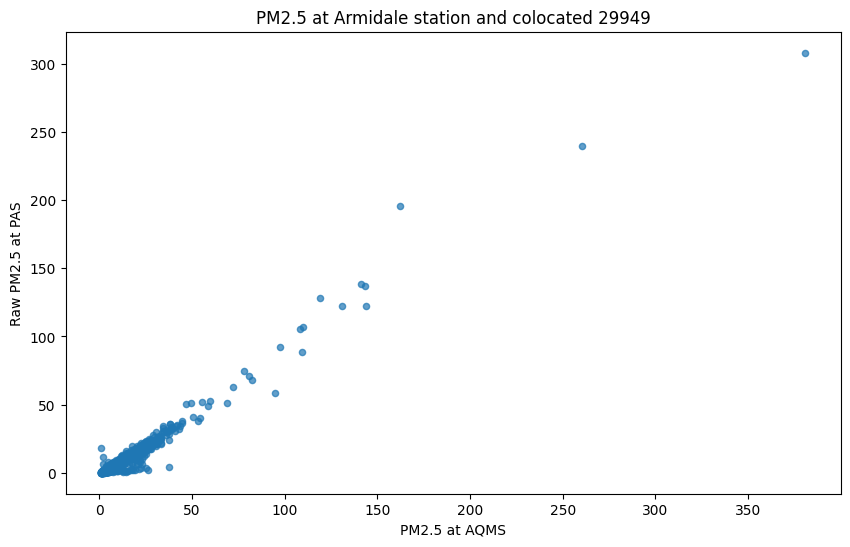

X datetime_utc
2019-04-02 00:00:00+00:00     2.279667
2019-04-04 00:00:00+00:00     0.985000
2019-05-10 00:00:00+00:00     4.367200
2019-05-11 00:00:00+00:00    16.948917
2019-05-12 00:00:00+00:00    25.412429
                               ...    
2024-05-25 00:00:00+00:00     9.762208
2024-05-26 00:00:00+00:00    12.270478
2024-05-27 00:00:00+00:00    16.400000
2024-05-28 00:00:00+00:00    18.419667
2024-05-29 00:00:00+00:00    23.034565
Name: PM2.5, Length: 1831, dtype: float64
filename:  fig\exploration\colocation\Armidale\scatter\20190401_20240531\PM2.5\Armidale_29949_pm2.5_corrected_20190401_20240531_daily.png


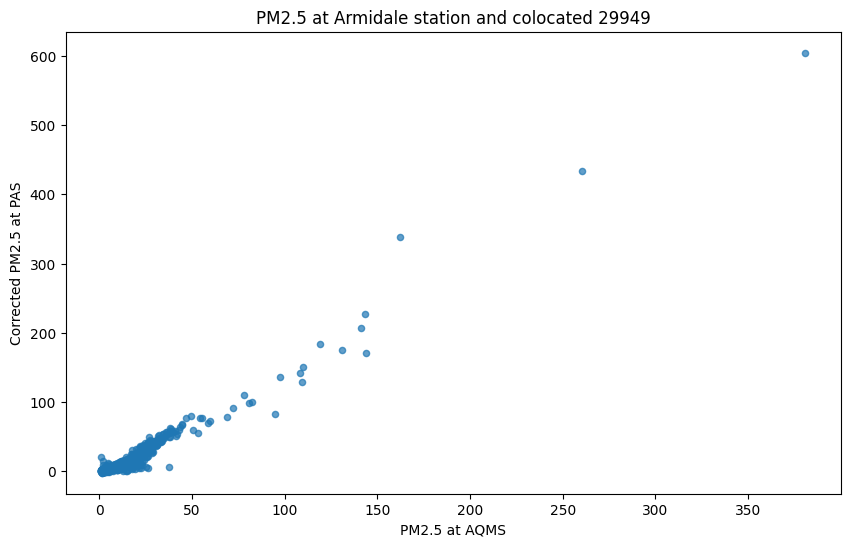

scatter plot data:  [(datetime_utc
2019-04-02 00:00:00+00:00     2.098429
2019-04-04 00:00:00+00:00     2.934375
2019-05-10 00:00:00+00:00    10.401125
2019-05-11 00:00:00+00:00    18.782292
2019-05-12 00:00:00+00:00    26.270478
                               ...    
2024-05-25 00:00:00+00:00     9.601087
2024-05-26 00:00:00+00:00    12.773455
2024-05-27 00:00:00+00:00    17.491625
2024-05-28 00:00:00+00:00    18.759417
2024-05-29 00:00:00+00:00    24.609652
Name: PM10, Length: 1817, dtype: float64, datetime_utc
2019-04-02 00:00:00+00:00    25.228
2019-04-04 00:00:00+00:00    39.945
2019-05-10 00:00:00+00:00     2.048
2019-05-11 00:00:00+00:00     2.954
2019-05-12 00:00:00+00:00     5.734
                              ...  
2024-05-25 00:00:00+00:00    19.362
2024-05-26 00:00:00+00:00    22.198
2024-05-27 00:00:00+00:00    31.071
2024-05-28 00:00:00+00:00    37.966
2024-05-29 00:00:00+00:00    43.762
Name: pm10.0_atm, Length: 1817, dtype: float64, ('PM10', 'pm10.0_atm'), '29949')]
X d

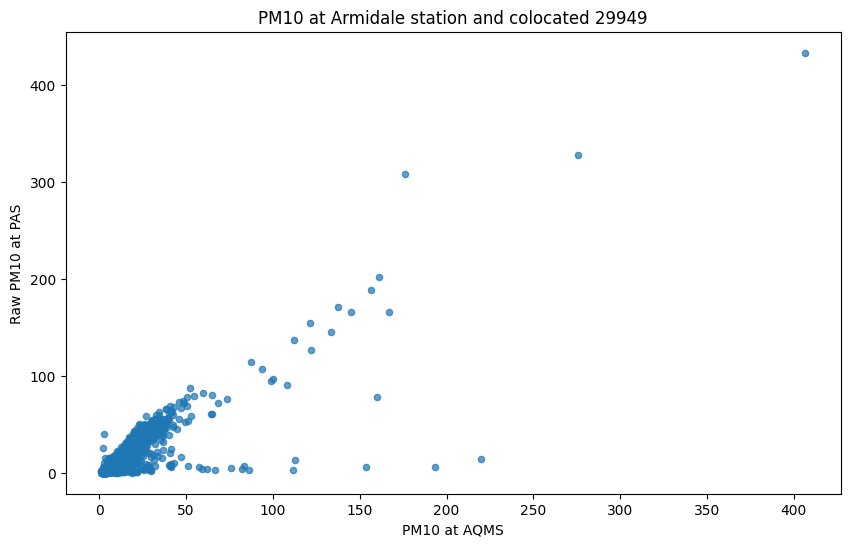

Site:  Bathurst
scatter plot data:  [(datetime_utc
2021-05-04 00:00:00+00:00    90.694167
2021-05-27 00:00:00+00:00    69.642583
2021-05-28 00:00:00+00:00    70.375833
2021-05-29 00:00:00+00:00    68.386375
2021-05-30 00:00:00+00:00    78.124542
                               ...    
2024-05-25 00:00:00+00:00    84.917792
2024-05-26 00:00:00+00:00    91.229000
2024-05-27 00:00:00+00:00    84.581375
2024-05-28 00:00:00+00:00    80.674292
2024-05-29 00:00:00+00:00    80.278708
Name: HUMID, Length: 1064, dtype: float64, datetime_utc
2021-05-04 00:00:00+00:00    56.000
2021-05-27 00:00:00+00:00    42.067
2021-05-28 00:00:00+00:00    40.606
2021-05-29 00:00:00+00:00    46.546
2021-05-30 00:00:00+00:00    53.664
                              ...  
2024-05-25 00:00:00+00:00    62.755
2024-05-26 00:00:00+00:00    65.996
2024-05-27 00:00:00+00:00    60.597
2024-05-28 00:00:00+00:00    56.489
2024-05-29 00:00:00+00:00    58.001
Name: humidity, Length: 1064, dtype: float64, ('HUMID', 'humidity'),

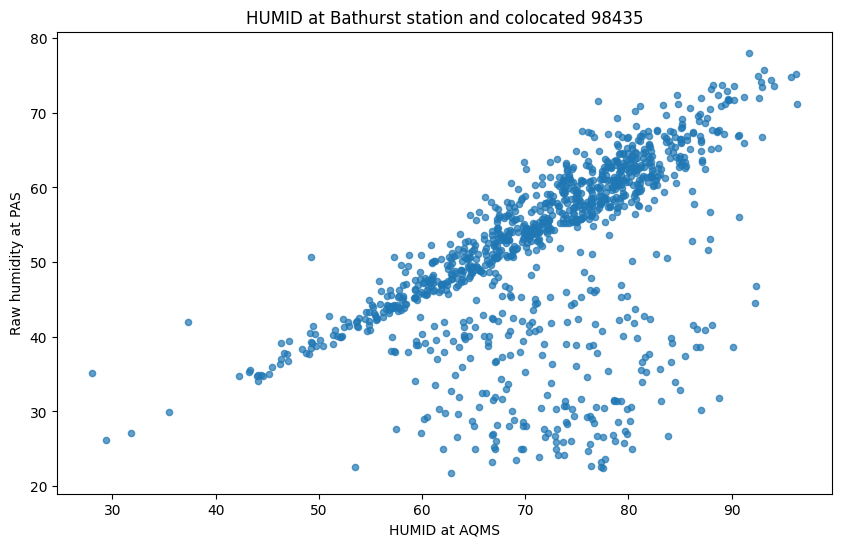

scatter plot data:  [(datetime_utc
2021-05-04 00:00:00+00:00    10.276792
2021-05-27 00:00:00+00:00     8.478250
2021-05-28 00:00:00+00:00     3.326708
2021-05-29 00:00:00+00:00     3.269167
2021-05-30 00:00:00+00:00     4.040875
                               ...    
2024-05-25 00:00:00+00:00     7.621500
2024-05-26 00:00:00+00:00     5.484042
2024-05-27 00:00:00+00:00     4.438708
2024-05-28 00:00:00+00:00     4.964333
2024-05-29 00:00:00+00:00     6.411875
Name: TEMP, Length: 1064, dtype: float64, datetime_utc
2021-05-04 00:00:00+00:00    21.9
2021-05-27 00:00:00+00:00    15.9
2021-05-28 00:00:00+00:00    13.1
2021-05-29 00:00:00+00:00    14.5
2021-05-30 00:00:00+00:00    14.8
                             ... 
2024-05-25 00:00:00+00:00    11.9
2024-05-26 00:00:00+00:00     9.5
2024-05-27 00:00:00+00:00     8.8
2024-05-28 00:00:00+00:00     9.9
2024-05-29 00:00:00+00:00    11.0
Name: temperature, Length: 1064, dtype: float64, ('TEMP', 'temperature'), '98435')]
X datetime_utc
2021-05-

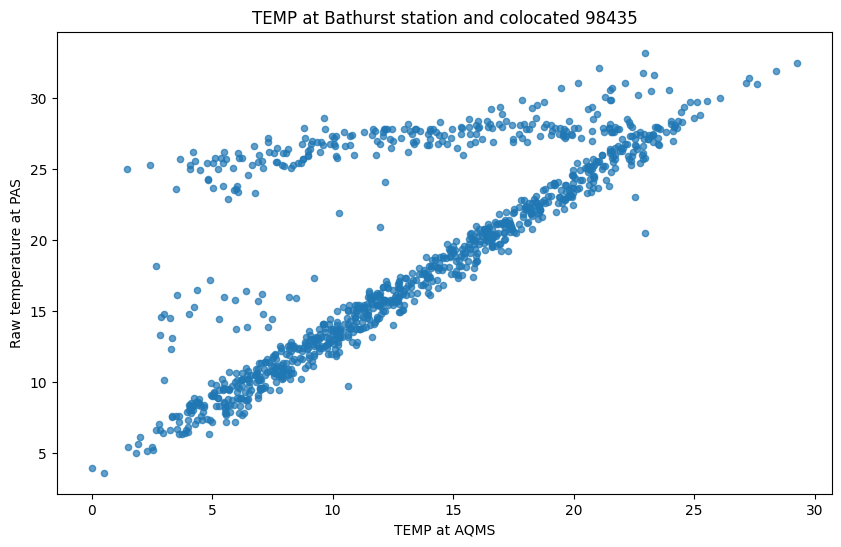

scatter plot data:  [(datetime_utc
2021-05-04 00:00:00+00:00     3.574913
2021-05-27 00:00:00+00:00     5.943833
2021-05-28 00:00:00+00:00     5.547750
2021-05-29 00:00:00+00:00     8.569909
2021-05-30 00:00:00+00:00     6.431944
                               ...    
2024-05-25 00:00:00+00:00    13.553875
2024-05-26 00:00:00+00:00     9.229391
2024-05-27 00:00:00+00:00    13.298417
2024-05-28 00:00:00+00:00    13.144417
2024-05-29 00:00:00+00:00    10.849261
Name: PM2.5, Length: 1048, dtype: float64, datetime_utc
2021-05-04 00:00:00+00:00    13.9
2021-05-27 00:00:00+00:00     0.7
2021-05-28 00:00:00+00:00     1.3
2021-05-29 00:00:00+00:00     1.3
2021-05-30 00:00:00+00:00     2.3
                             ... 
2024-05-25 00:00:00+00:00    12.0
2024-05-26 00:00:00+00:00    12.2
2024-05-27 00:00:00+00:00    13.5
2024-05-28 00:00:00+00:00    11.2
2024-05-29 00:00:00+00:00    10.2
Name: pm2.5_alt, Length: 1048, dtype: float64, ('PM2.5', 'pm2.5_alt'), '98435'), (datetime_utc
2021-05-04 

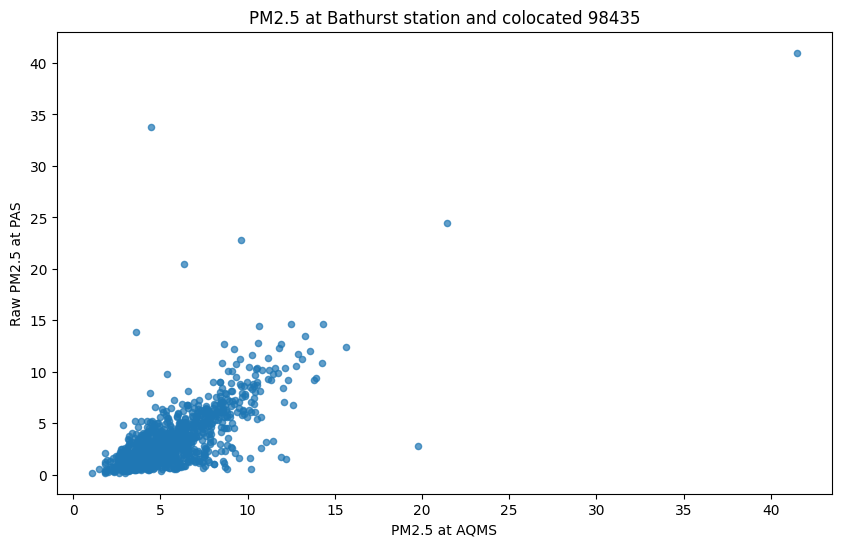

X datetime_utc
2021-05-04 00:00:00+00:00     3.574913
2021-05-27 00:00:00+00:00     5.943833
2021-05-28 00:00:00+00:00     5.547750
2021-05-29 00:00:00+00:00     8.569909
2021-05-30 00:00:00+00:00     6.431944
                               ...    
2024-05-25 00:00:00+00:00    13.553875
2024-05-26 00:00:00+00:00     9.229391
2024-05-27 00:00:00+00:00    13.298417
2024-05-28 00:00:00+00:00    13.144417
2024-05-29 00:00:00+00:00    10.849261
Name: PM2.5, Length: 1048, dtype: float64
filename:  fig\exploration\colocation\Bathurst\scatter\20210201_20240531\PM2.5\Bathurst_98435_pm2.5_corrected_20210201_20240531_daily.png


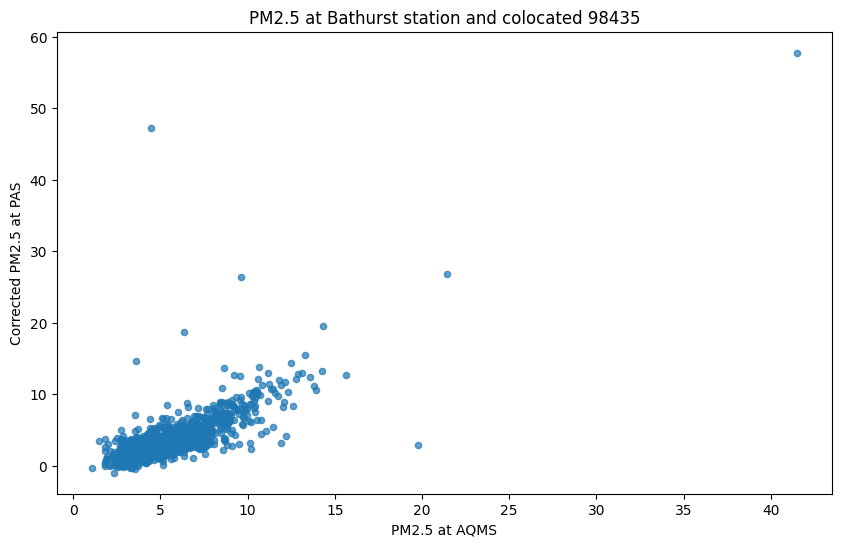

scatter plot data:  [(datetime_utc
2021-05-04 00:00:00+00:00     6.018000
2021-05-27 00:00:00+00:00     6.996167
2021-05-28 00:00:00+00:00     9.714083
2021-05-29 00:00:00+00:00    11.195000
2021-05-30 00:00:00+00:00     7.127542
                               ...    
2024-05-25 00:00:00+00:00    15.123583
2024-05-26 00:00:00+00:00    11.676875
2024-05-27 00:00:00+00:00    17.370167
2024-05-28 00:00:00+00:00    19.079042
2024-05-29 00:00:00+00:00    16.559500
Name: PM10, Length: 1058, dtype: float64, datetime_utc
2021-05-04 00:00:00+00:00    29.150
2021-05-27 00:00:00+00:00     0.396
2021-05-28 00:00:00+00:00     1.385
2021-05-29 00:00:00+00:00     1.404
2021-05-30 00:00:00+00:00     3.101
                              ...  
2024-05-25 00:00:00+00:00    27.276
2024-05-26 00:00:00+00:00    28.658
2024-05-27 00:00:00+00:00    34.038
2024-05-28 00:00:00+00:00    27.998
2024-05-29 00:00:00+00:00    23.876
Name: pm10.0_atm, Length: 1058, dtype: float64, ('PM10', 'pm10.0_atm'), '98435')]
X d

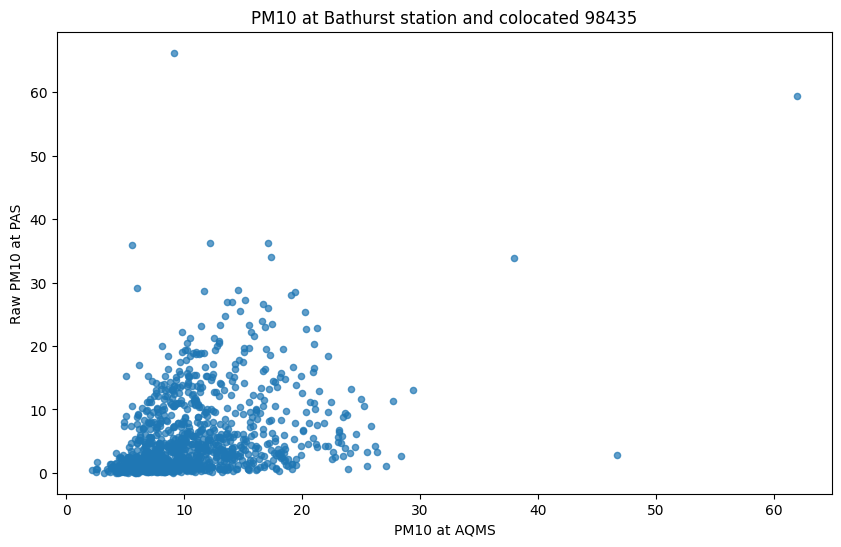

Site:  Lidcombe
scatter plot data:  [(datetime_utc
2021-02-28 00:00:00+00:00    88.666100
2021-03-01 00:00:00+00:00    66.566875
2021-03-02 00:00:00+00:00    58.344435
2021-03-03 00:00:00+00:00    63.645250
2021-03-04 00:00:00+00:00    60.290417
                               ...    
2023-12-25 00:00:00+00:00    77.769792
2023-12-26 00:00:00+00:00    78.405750
2023-12-27 00:00:00+00:00    78.933917
2023-12-28 00:00:00+00:00    67.370625
2023-12-29 00:00:00+00:00    67.506083
Name: HUMID, Length: 1021, dtype: float64, datetime_utc
2021-02-28 00:00:00+00:00    41.968
2021-03-01 00:00:00+00:00    40.790
2021-03-02 00:00:00+00:00    35.851
2021-03-03 00:00:00+00:00    35.897
2021-03-04 00:00:00+00:00    35.528
                              ...  
2023-12-25 00:00:00+00:00    56.926
2023-12-26 00:00:00+00:00    55.876
2023-12-27 00:00:00+00:00    55.514
2023-12-28 00:00:00+00:00    47.378
2023-12-29 00:00:00+00:00    48.112
Name: humidity, Length: 1021, dtype: float64, ('HUMID', 'humidity'),

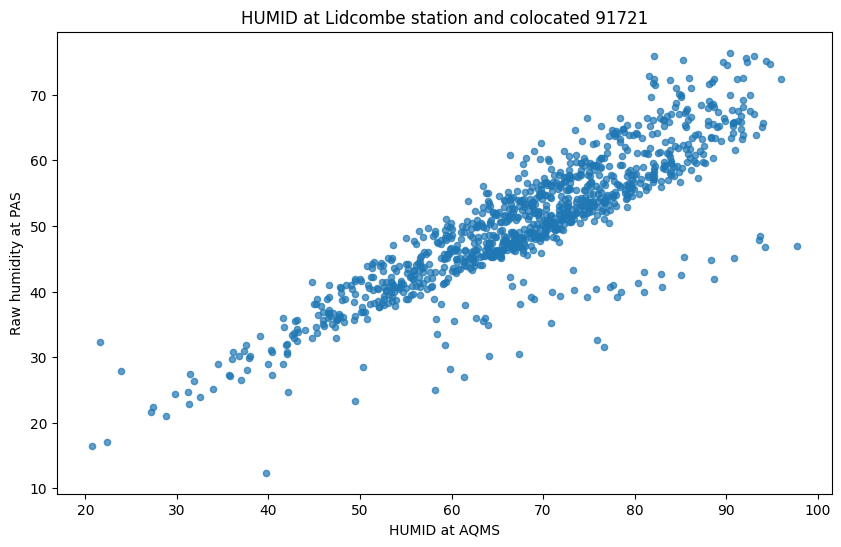

X datetime_utc
2021-02-28 00:00:00+00:00    88.666100
2021-03-01 00:00:00+00:00    66.566875
2021-03-02 00:00:00+00:00    58.344435
2021-03-03 00:00:00+00:00    63.645250
2021-03-04 00:00:00+00:00    60.290417
                               ...    
2023-12-25 00:00:00+00:00    77.769792
2023-12-26 00:00:00+00:00    78.405750
2023-12-27 00:00:00+00:00    78.933917
2023-12-28 00:00:00+00:00    67.370625
2023-12-29 00:00:00+00:00    67.506083
Name: HUMID, Length: 982, dtype: float64
filename:  fig\exploration\colocation\Lidcombe\scatter\20210301_20231231\HUMID\Lidcombe_92367_humidity_20210301_20231231_daily.png


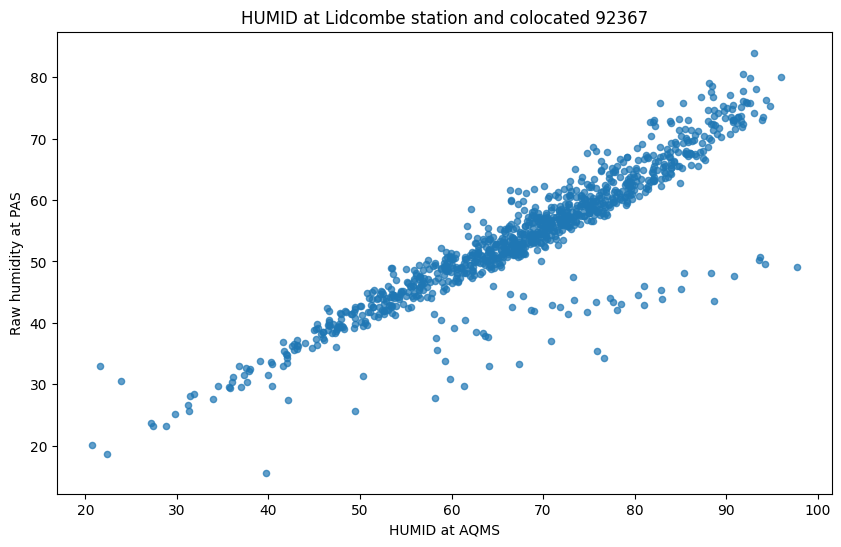

X datetime_utc
2021-02-28 00:00:00+00:00    88.666100
2021-03-01 00:00:00+00:00    66.566875
2021-03-02 00:00:00+00:00    58.344435
2021-03-03 00:00:00+00:00    63.645250
2021-03-04 00:00:00+00:00    60.290417
                               ...    
2023-12-25 00:00:00+00:00    77.769792
2023-12-26 00:00:00+00:00    78.405750
2023-12-27 00:00:00+00:00    78.933917
2023-12-28 00:00:00+00:00    67.370625
2023-12-29 00:00:00+00:00    67.506083
Name: HUMID, Length: 1015, dtype: float64
filename:  fig\exploration\colocation\Lidcombe\scatter\20210301_20231231\HUMID\Lidcombe_91355_humidity_20210301_20231231_daily.png


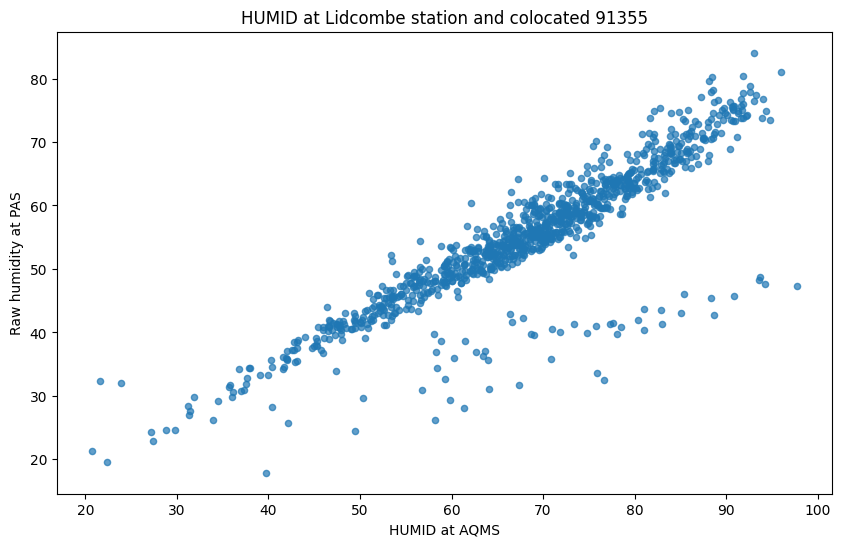

scatter plot data:  [(datetime_utc
2021-02-28 00:00:00+00:00    21.307600
2021-03-01 00:00:00+00:00    25.288125
2021-03-02 00:00:00+00:00    19.950522
2021-03-03 00:00:00+00:00    18.724750
2021-03-04 00:00:00+00:00    21.963917
                               ...    
2023-12-25 00:00:00+00:00    23.197542
2023-12-26 00:00:00+00:00    22.995792
2023-12-27 00:00:00+00:00    20.308208
2023-12-28 00:00:00+00:00    23.096708
2023-12-29 00:00:00+00:00    22.482292
Name: TEMP, Length: 1021, dtype: float64, datetime_utc
2021-02-28 00:00:00+00:00    28.8
2021-03-01 00:00:00+00:00    28.1
2021-03-02 00:00:00+00:00    27.6
2021-03-03 00:00:00+00:00    27.4
2021-03-04 00:00:00+00:00    27.7
                             ... 
2023-12-25 00:00:00+00:00    27.4
2023-12-26 00:00:00+00:00    27.6
2023-12-27 00:00:00+00:00    25.1
2023-12-28 00:00:00+00:00    27.9
2023-12-29 00:00:00+00:00    27.0
Name: temperature, Length: 1021, dtype: float64, ('TEMP', 'temperature'), '91721'), (datetime_utc
2021-02-2

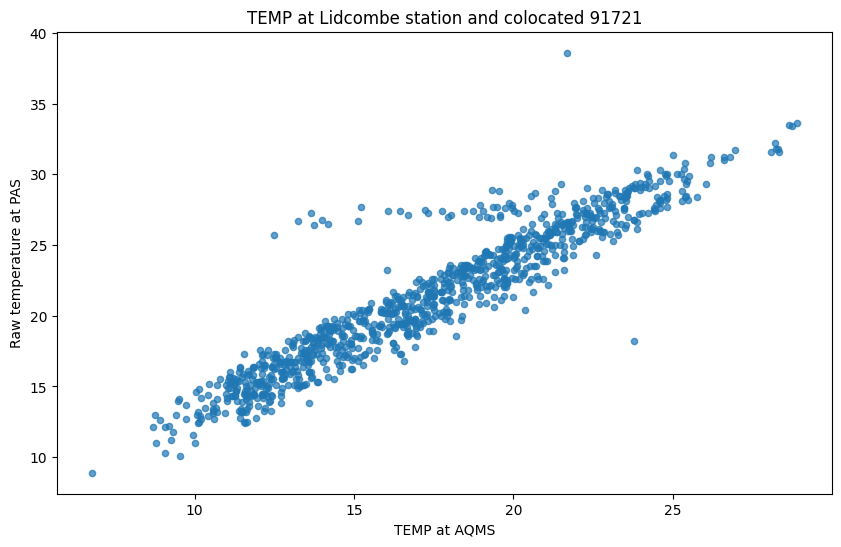

X datetime_utc
2021-02-28 00:00:00+00:00    21.307600
2021-03-01 00:00:00+00:00    25.288125
2021-03-02 00:00:00+00:00    19.950522
2021-03-03 00:00:00+00:00    18.724750
2021-03-04 00:00:00+00:00    21.963917
                               ...    
2023-12-25 00:00:00+00:00    23.197542
2023-12-26 00:00:00+00:00    22.995792
2023-12-27 00:00:00+00:00    20.308208
2023-12-28 00:00:00+00:00    23.096708
2023-12-29 00:00:00+00:00    22.482292
Name: TEMP, Length: 982, dtype: float64
filename:  fig\exploration\colocation\Lidcombe\scatter\20210301_20231231\TEMP\Lidcombe_92367_temperature_20210301_20231231_daily.png


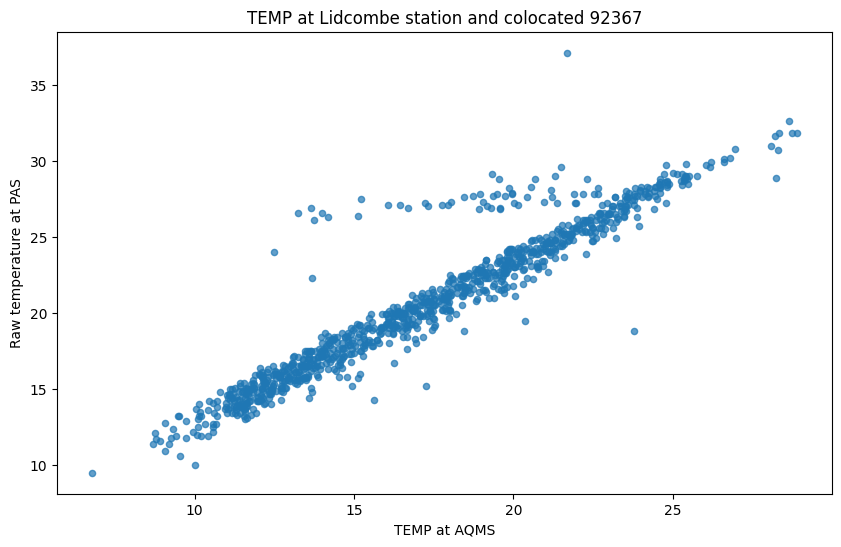

X datetime_utc
2021-02-28 00:00:00+00:00    21.307600
2021-03-01 00:00:00+00:00    25.288125
2021-03-02 00:00:00+00:00    19.950522
2021-03-03 00:00:00+00:00    18.724750
2021-03-04 00:00:00+00:00    21.963917
                               ...    
2023-12-25 00:00:00+00:00    23.197542
2023-12-26 00:00:00+00:00    22.995792
2023-12-27 00:00:00+00:00    20.308208
2023-12-28 00:00:00+00:00    23.096708
2023-12-29 00:00:00+00:00    22.482292
Name: TEMP, Length: 1015, dtype: float64
filename:  fig\exploration\colocation\Lidcombe\scatter\20210301_20231231\TEMP\Lidcombe_91355_temperature_20210301_20231231_daily.png


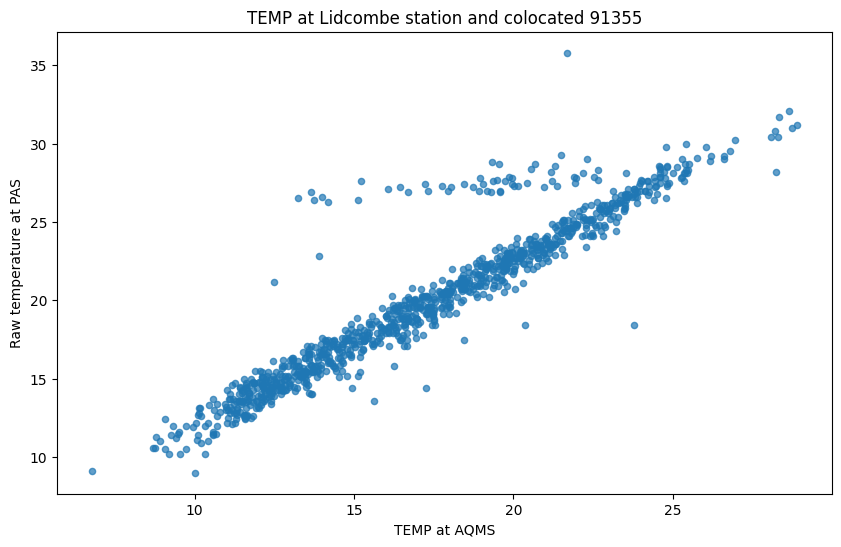

scatter plot data:  [(datetime_utc
2021-02-28 00:00:00+00:00     5.569556
2021-03-01 00:00:00+00:00    12.166652
2021-03-02 00:00:00+00:00     8.284304
2021-03-03 00:00:00+00:00     6.212130
2021-03-04 00:00:00+00:00     7.314043
                               ...    
2023-12-25 00:00:00+00:00     7.471250
2023-12-26 00:00:00+00:00     6.095458
2023-12-27 00:00:00+00:00     6.291348
2023-12-28 00:00:00+00:00     6.316125
2023-12-29 00:00:00+00:00     4.753824
Name: PM2.5, Length: 1016, dtype: float64, datetime_utc
2021-02-28 00:00:00+00:00    4.7
2021-03-01 00:00:00+00:00    8.0
2021-03-02 00:00:00+00:00    2.0
2021-03-03 00:00:00+00:00    2.3
2021-03-04 00:00:00+00:00    3.6
                            ... 
2023-12-25 00:00:00+00:00    2.1
2023-12-26 00:00:00+00:00    3.7
2023-12-27 00:00:00+00:00    3.4
2023-12-28 00:00:00+00:00    2.5
2023-12-29 00:00:00+00:00    2.4
Name: pm2.5_alt, Length: 1016, dtype: float64, ('PM2.5', 'pm2.5_alt'), '91721'), (datetime_utc
2021-02-28 00:00:00+00

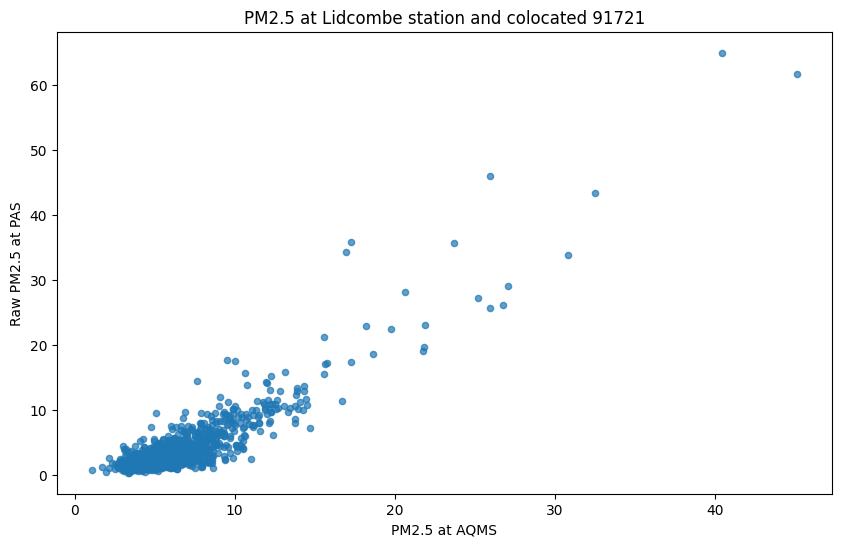

X datetime_utc
2021-02-28 00:00:00+00:00     5.569556
2021-03-01 00:00:00+00:00    12.166652
2021-03-02 00:00:00+00:00     8.284304
2021-03-03 00:00:00+00:00     6.212130
2021-03-04 00:00:00+00:00     7.314043
                               ...    
2023-12-25 00:00:00+00:00     7.471250
2023-12-26 00:00:00+00:00     6.095458
2023-12-27 00:00:00+00:00     6.291348
2023-12-28 00:00:00+00:00     6.316125
2023-12-29 00:00:00+00:00     4.753824
Name: PM2.5, Length: 977, dtype: float64
filename:  fig\exploration\colocation\Lidcombe\scatter\20210301_20231231\PM2.5\Lidcombe_92367_pm2.5_alt_20210301_20231231_daily.png


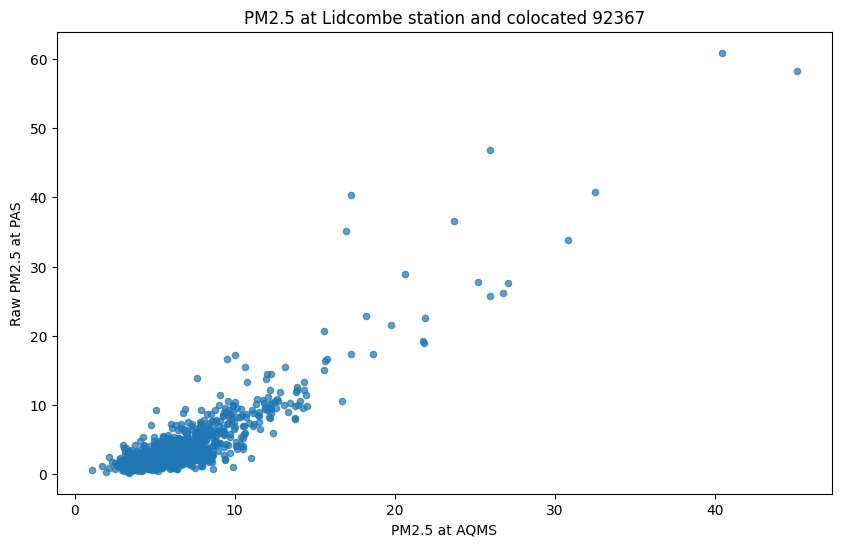

X datetime_utc
2021-02-28 00:00:00+00:00     5.569556
2021-03-01 00:00:00+00:00    12.166652
2021-03-02 00:00:00+00:00     8.284304
2021-03-03 00:00:00+00:00     6.212130
2021-03-04 00:00:00+00:00     7.314043
                               ...    
2023-12-25 00:00:00+00:00     7.471250
2023-12-26 00:00:00+00:00     6.095458
2023-12-27 00:00:00+00:00     6.291348
2023-12-28 00:00:00+00:00     6.316125
2023-12-29 00:00:00+00:00     4.753824
Name: PM2.5, Length: 1010, dtype: float64
filename:  fig\exploration\colocation\Lidcombe\scatter\20210301_20231231\PM2.5\Lidcombe_91355_pm2.5_alt_20210301_20231231_daily.png


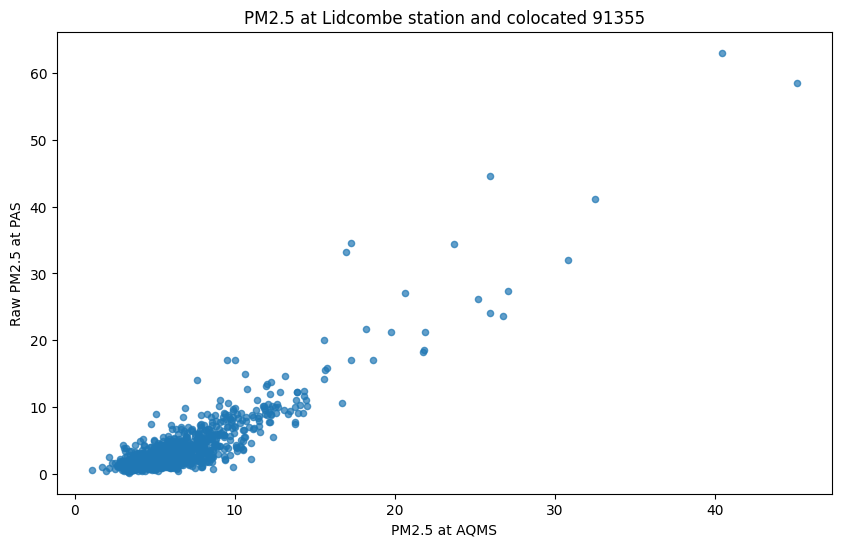

X datetime_utc
2021-02-28 00:00:00+00:00     5.569556
2021-03-01 00:00:00+00:00    12.166652
2021-03-02 00:00:00+00:00     8.284304
2021-03-03 00:00:00+00:00     6.212130
2021-03-04 00:00:00+00:00     7.314043
                               ...    
2023-12-25 00:00:00+00:00     7.471250
2023-12-26 00:00:00+00:00     6.095458
2023-12-27 00:00:00+00:00     6.291348
2023-12-28 00:00:00+00:00     6.316125
2023-12-29 00:00:00+00:00     4.753824
Name: PM2.5, Length: 1016, dtype: float64
filename:  fig\exploration\colocation\Lidcombe\scatter\20210301_20231231\PM2.5\Lidcombe_91721_pm2.5_corrected_20210301_20231231_daily.png


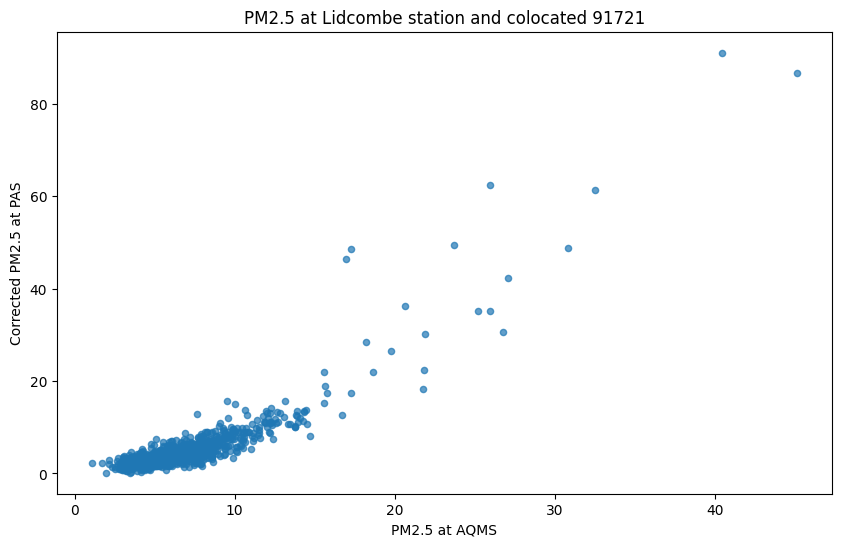

X datetime_utc
2021-02-28 00:00:00+00:00     5.569556
2021-03-01 00:00:00+00:00    12.166652
2021-03-02 00:00:00+00:00     8.284304
2021-03-03 00:00:00+00:00     6.212130
2021-03-04 00:00:00+00:00     7.314043
                               ...    
2023-12-25 00:00:00+00:00     7.471250
2023-12-26 00:00:00+00:00     6.095458
2023-12-27 00:00:00+00:00     6.291348
2023-12-28 00:00:00+00:00     6.316125
2023-12-29 00:00:00+00:00     4.753824
Name: PM2.5, Length: 977, dtype: float64
filename:  fig\exploration\colocation\Lidcombe\scatter\20210301_20231231\PM2.5\Lidcombe_92367_pm2.5_corrected_20210301_20231231_daily.png


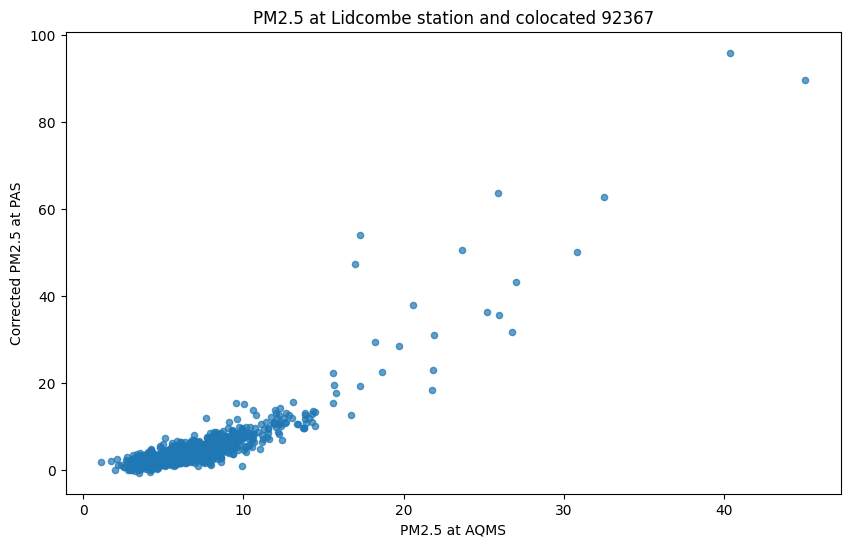

X datetime_utc
2021-02-28 00:00:00+00:00     5.569556
2021-03-01 00:00:00+00:00    12.166652
2021-03-02 00:00:00+00:00     8.284304
2021-03-03 00:00:00+00:00     6.212130
2021-03-04 00:00:00+00:00     7.314043
                               ...    
2023-12-25 00:00:00+00:00     7.471250
2023-12-26 00:00:00+00:00     6.095458
2023-12-27 00:00:00+00:00     6.291348
2023-12-28 00:00:00+00:00     6.316125
2023-12-29 00:00:00+00:00     4.753824
Name: PM2.5, Length: 1010, dtype: float64
filename:  fig\exploration\colocation\Lidcombe\scatter\20210301_20231231\PM2.5\Lidcombe_91355_pm2.5_corrected_20210301_20231231_daily.png


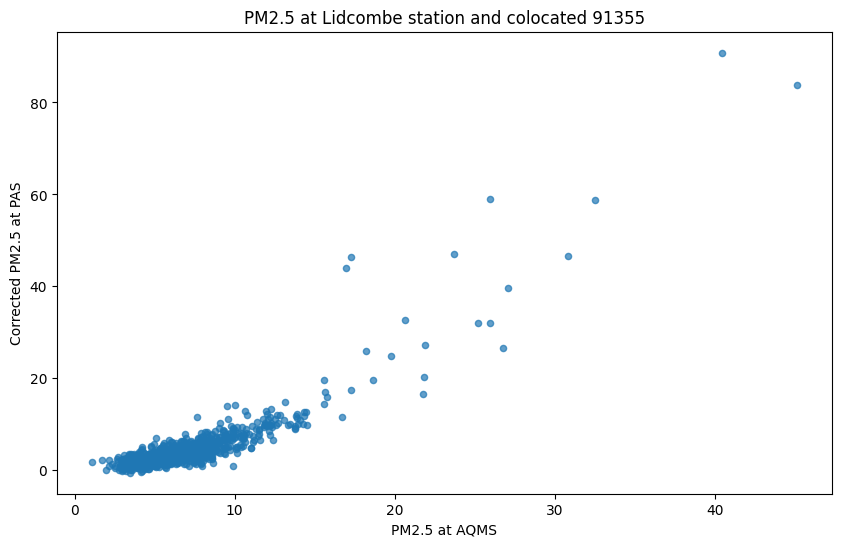

scatter plot data:  [(datetime_utc
2021-02-28 00:00:00+00:00    18.335200
2021-03-01 00:00:00+00:00    34.344435
2021-03-02 00:00:00+00:00    25.429136
2021-03-03 00:00:00+00:00    15.197087
2021-03-04 00:00:00+00:00    17.318458
                               ...    
2023-12-25 00:00:00+00:00    17.761042
2023-12-26 00:00:00+00:00    19.143375
2023-12-27 00:00:00+00:00    16.508750
2023-12-28 00:00:00+00:00    13.389083
2023-12-29 00:00:00+00:00    12.509652
Name: PM10, Length: 1019, dtype: float64, datetime_utc
2021-02-28 00:00:00+00:00     7.262
2021-03-01 00:00:00+00:00    13.178
2021-03-02 00:00:00+00:00     2.930
2021-03-03 00:00:00+00:00     3.249
2021-03-04 00:00:00+00:00     5.686
                              ...  
2023-12-25 00:00:00+00:00     3.348
2023-12-26 00:00:00+00:00     6.114
2023-12-27 00:00:00+00:00     5.432
2023-12-28 00:00:00+00:00     3.771
2023-12-29 00:00:00+00:00     3.662
Name: pm10.0_atm, Length: 1019, dtype: float64, ('PM10', 'pm10.0_atm'), '91721'), (da

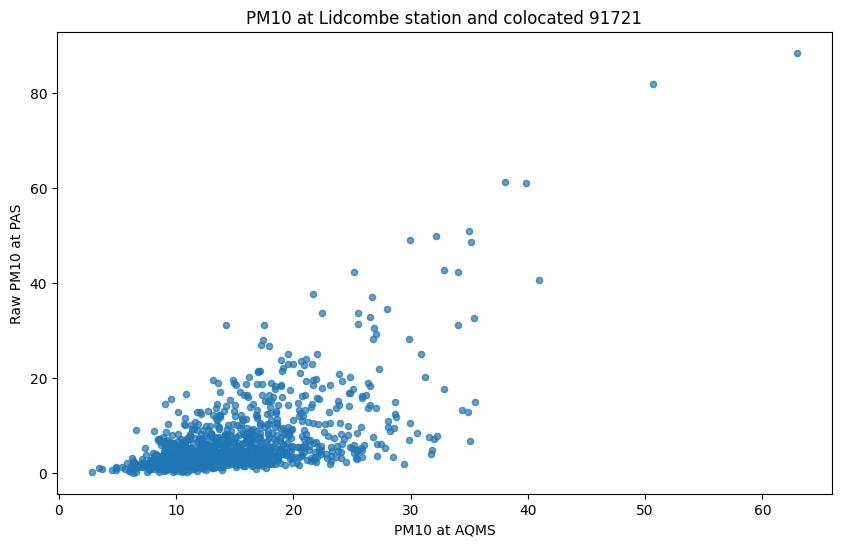

X datetime_utc
2021-02-28 00:00:00+00:00    18.335200
2021-03-01 00:00:00+00:00    34.344435
2021-03-02 00:00:00+00:00    25.429136
2021-03-03 00:00:00+00:00    15.197087
2021-03-04 00:00:00+00:00    17.318458
                               ...    
2023-12-25 00:00:00+00:00    17.761042
2023-12-26 00:00:00+00:00    19.143375
2023-12-27 00:00:00+00:00    16.508750
2023-12-28 00:00:00+00:00    13.389083
2023-12-29 00:00:00+00:00    12.509652
Name: PM10, Length: 980, dtype: float64
filename:  fig\exploration\colocation\Lidcombe\scatter\20210301_20231231\PM10\Lidcombe_92367_pm10.0_atm_20210301_20231231_daily.png


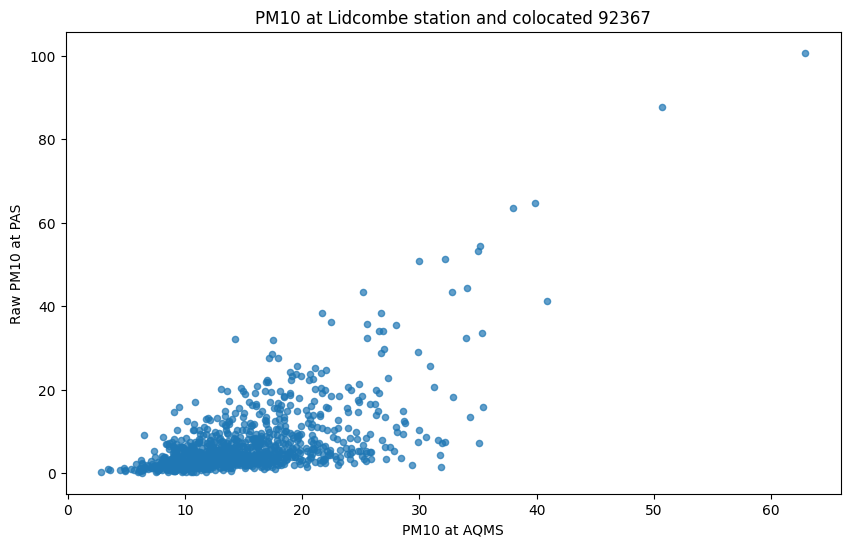

X datetime_utc
2021-02-28 00:00:00+00:00    18.335200
2021-03-01 00:00:00+00:00    34.344435
2021-03-02 00:00:00+00:00    25.429136
2021-03-03 00:00:00+00:00    15.197087
2021-03-04 00:00:00+00:00    17.318458
                               ...    
2023-12-25 00:00:00+00:00    17.761042
2023-12-26 00:00:00+00:00    19.143375
2023-12-27 00:00:00+00:00    16.508750
2023-12-28 00:00:00+00:00    13.389083
2023-12-29 00:00:00+00:00    12.509652
Name: PM10, Length: 1013, dtype: float64
filename:  fig\exploration\colocation\Lidcombe\scatter\20210301_20231231\PM10\Lidcombe_91355_pm10.0_atm_20210301_20231231_daily.png


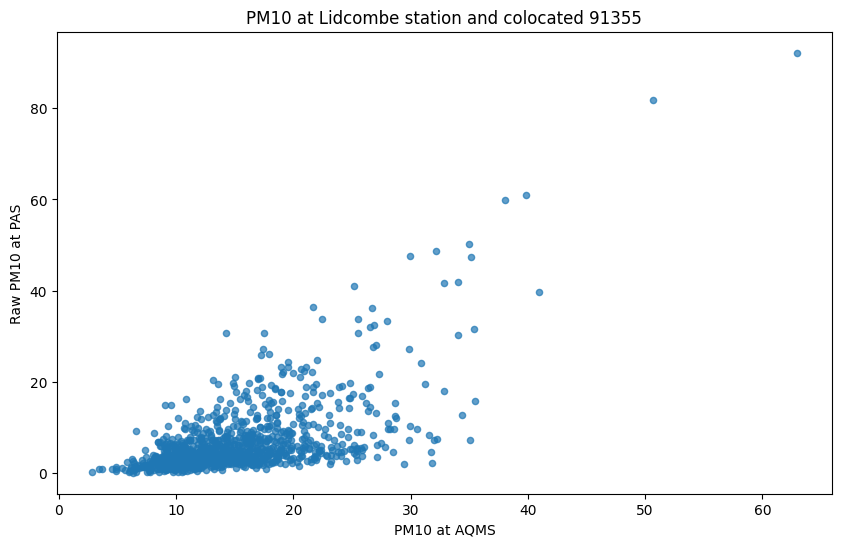

Site:  Millthorpe
scatter plot data:  [(datetime_utc
2023-07-27 00:00:00+00:00    78.638333
2023-07-28 00:00:00+00:00    76.364800
2023-07-29 00:00:00+00:00    92.580778
2023-07-30 00:00:00+00:00    82.991750
2023-07-31 00:00:00+00:00    82.685625
                               ...    
2024-05-25 00:00:00+00:00    81.861292
2024-05-26 00:00:00+00:00    79.804667
2024-05-27 00:00:00+00:00    76.624625
2024-05-28 00:00:00+00:00    67.411750
2024-05-29 00:00:00+00:00    70.795208
Name: HUMID, Length: 301, dtype: float64, datetime_utc
2023-07-27 00:00:00+00:00    48.667
2023-07-28 00:00:00+00:00    53.738
2023-07-29 00:00:00+00:00    53.242
2023-07-30 00:00:00+00:00    54.338
2023-07-31 00:00:00+00:00    55.990
                              ...  
2024-05-25 00:00:00+00:00    53.389
2024-05-26 00:00:00+00:00    51.689
2024-05-27 00:00:00+00:00    50.799
2024-05-28 00:00:00+00:00    45.890
2024-05-29 00:00:00+00:00    48.459
Name: humidity, Length: 301, dtype: float64, ('HUMID', 'humidity'),

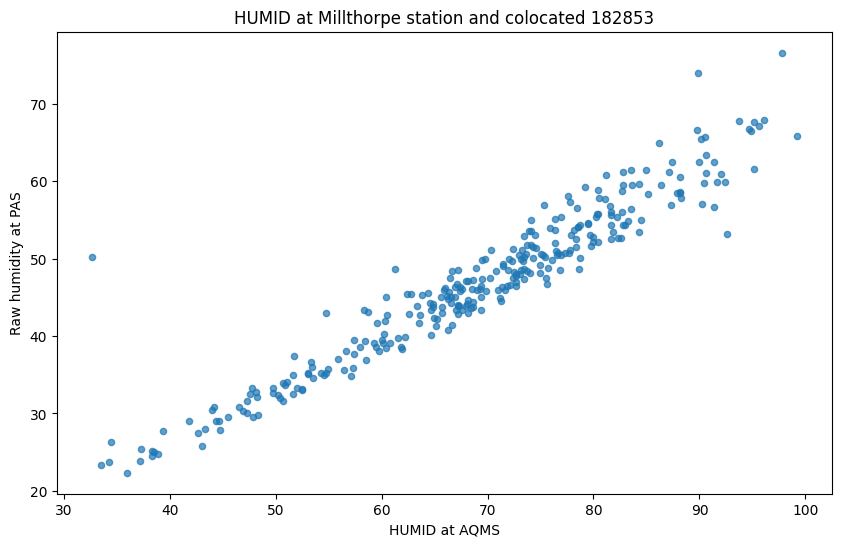

scatter plot data:  [(datetime_utc
2023-07-27 00:00:00+00:00     7.176667
2023-07-28 00:00:00+00:00    10.395267
2023-07-29 00:00:00+00:00     7.998778
2023-07-30 00:00:00+00:00     9.002417
2023-07-31 00:00:00+00:00     7.244542
                               ...    
2024-05-25 00:00:00+00:00     8.501250
2024-05-26 00:00:00+00:00     8.095500
2024-05-27 00:00:00+00:00     7.392917
2024-05-28 00:00:00+00:00     9.733292
2024-05-29 00:00:00+00:00    10.364917
Name: TEMP, Length: 301, dtype: float64, datetime_utc
2023-07-27 00:00:00+00:00    14.3
2023-07-28 00:00:00+00:00    15.2
2023-07-29 00:00:00+00:00    16.2
2023-07-30 00:00:00+00:00    14.6
2023-07-31 00:00:00+00:00    12.4
                             ... 
2024-05-25 00:00:00+00:00    15.0
2024-05-26 00:00:00+00:00    14.7
2024-05-27 00:00:00+00:00    13.8
2024-05-28 00:00:00+00:00    15.7
2024-05-29 00:00:00+00:00    16.2
Name: temperature, Length: 301, dtype: float64, ('TEMP', 'temperature'), '182853')]
X datetime_utc
2023-07-2

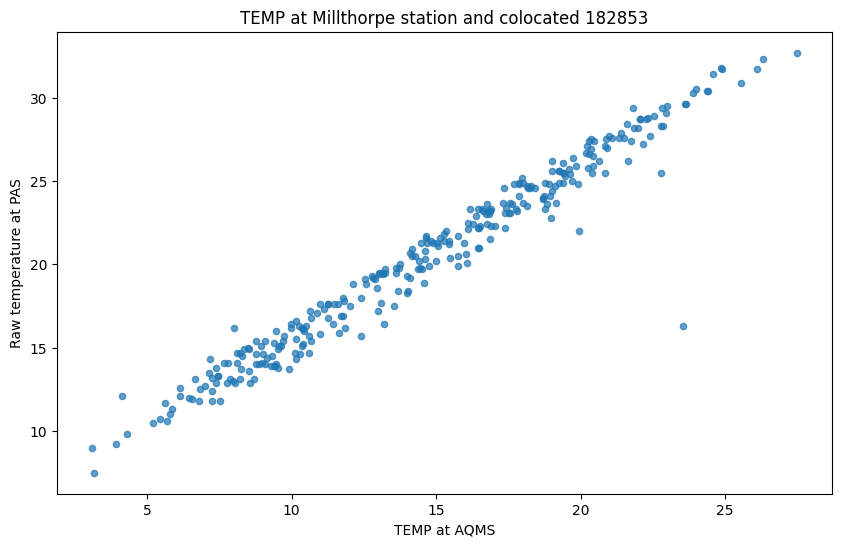

scatter plot data:  [(datetime_utc
2023-07-27 00:00:00+00:00     6.036000
2023-07-28 00:00:00+00:00     6.379067
2023-07-29 00:00:00+00:00     7.242889
2023-07-30 00:00:00+00:00     8.295167
2023-07-31 00:00:00+00:00     4.553458
                               ...    
2024-05-25 00:00:00+00:00    10.175333
2024-05-26 00:00:00+00:00    11.467583
2024-05-27 00:00:00+00:00    14.899667
2024-05-28 00:00:00+00:00    14.050250
2024-05-29 00:00:00+00:00    16.307250
Name: PM2.5, Length: 283, dtype: float64, datetime_utc
2023-07-27 00:00:00+00:00     3.3
2023-07-28 00:00:00+00:00     3.0
2023-07-29 00:00:00+00:00     3.2
2023-07-30 00:00:00+00:00     4.5
2023-07-31 00:00:00+00:00     1.2
                             ... 
2024-05-25 00:00:00+00:00     7.5
2024-05-26 00:00:00+00:00     8.3
2024-05-27 00:00:00+00:00    10.7
2024-05-28 00:00:00+00:00     9.2
2024-05-29 00:00:00+00:00    11.5
Name: pm2.5_alt, Length: 283, dtype: float64, ('PM2.5', 'pm2.5_alt'), '182853'), (datetime_utc
2023-07-27 0

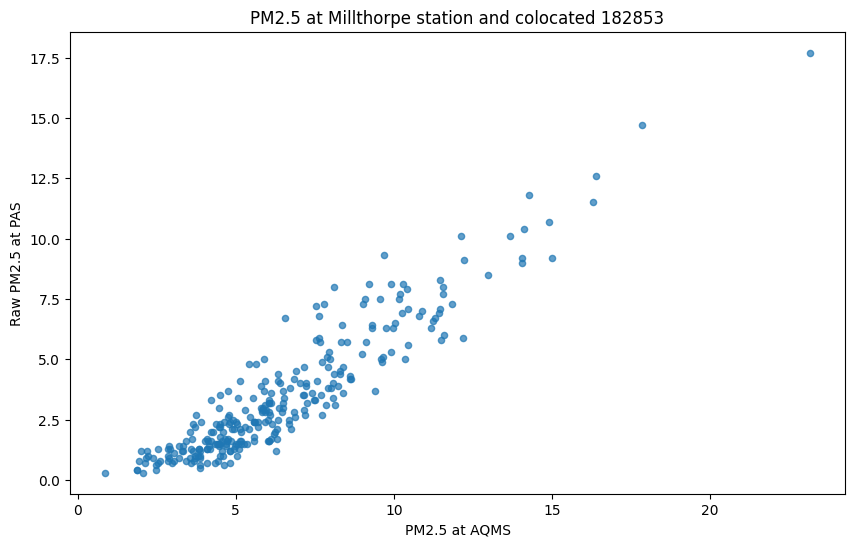

X datetime_utc
2023-07-27 00:00:00+00:00     6.036000
2023-07-28 00:00:00+00:00     6.379067
2023-07-29 00:00:00+00:00     7.242889
2023-07-30 00:00:00+00:00     8.295167
2023-07-31 00:00:00+00:00     4.553458
                               ...    
2024-05-25 00:00:00+00:00    10.175333
2024-05-26 00:00:00+00:00    11.467583
2024-05-27 00:00:00+00:00    14.899667
2024-05-28 00:00:00+00:00    14.050250
2024-05-29 00:00:00+00:00    16.307250
Name: PM2.5, Length: 283, dtype: float64
filename:  fig\exploration\colocation\Millthorpe\scatter\20230701_20240531\PM2.5\Millthorpe_182853_pm2.5_corrected_20230701_20240531_daily.png


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\13993807_admin\\OneDrive - UTS\\HDR\\DPE\\Data_fusion_project\\Project\\Coding\\nowcasting_framework\\src\\visualization\\climatology\\fig\\exploration\\colocation\\Millthorpe\\scatter\\20230701_20240531\\PM2.5\\Millthorpe_182853_pm2.5_corrected_20230701_20240531_daily.png'

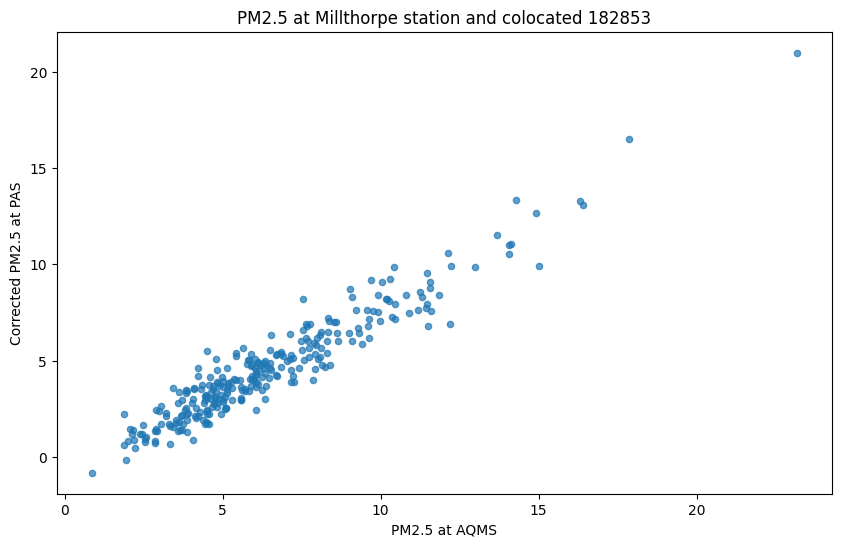

In [4]:
def load_and_prepare_all_sites(metadata_file, freq):
    metadata = load_colocation_data(metadata_file)

    for location, details in metadata.items():
        aqms_details = details.get("AQMS", {})
        site_id = details["AQMS"]["site_id"]
        aqms_start_date, aqms_end_date = aqms_details["data_range"]

        sensors = details.get("PAS", {})
        pas_filepaths = {}
        for sensor_id, sensor_details in sensors.items():
            sensor_start_date, sensor_end_date = sensor_details["data_range"]

            start_date = max(aqms_start_date, sensor_start_date)
            end_date = min(aqms_end_date, sensor_end_date)

            start_date_formatted = start_date.replace("-", "")
            end_date_formatted = end_date.replace("-", "")
            aqms_filepath = f"../../../data/processed/colocation/{location}/AQMS/{start_date_formatted}_{end_date_formatted}/aqms_{site_id}_{start_date_formatted}_{end_date_formatted}_{freq}.csv"
            pas_filepath = f"../../../data/processed/colocation/{location}/PAS/{sensor_id}/{start_date_formatted}_{end_date_formatted}/pas_{sensor_id}_{start_date_formatted}_{end_date_formatted}_{freq}.csv"
            pas_filepaths[sensor_id] = pas_filepath

        aqms_data, pas_data = load_site_data(
            aqms_filepath,
            pas_filepaths,
        )
        print("Site: ", location)
        parameters = list(HEADER_MAPPING.keys())

        for parameter in parameters:
            scatter_data = prepare_scatter_plot_data(
                aqms_data, pas_data, parameter, HEADER_MAPPING
            )

            print("scatter plot data: ", scatter_data)

            # if location == "Wagga_Wagga_North":
            #     location = "Wagga_Wagga"
            folderpathdir = os.path.join(
                "fig",
                "exploration",
                "colocation",
                location,
                "scatter",
                f"{start_date_formatted}_{end_date_formatted}",
                parameter,
            )

            if not os.path.exists(folderpathdir):
                os.makedirs(folderpathdir)

            for x, y, dual_param, pas_id in scatter_data:
                print("X", x)
                filename = os.path.join(
                    folderpathdir,
                    f"{location}_{pas_id}_{dual_param[1]}_{start_date_formatted}_{end_date_formatted}_{freq}.png",
                )
                print("filename: ", filename)
                scatter_plot(
                    x,
                    y,
                    title=f"{parameter} at {location} station and colocated {pas_id}",
                    xlabel=f"{dual_param[0]} at AQMS",
                    ylabel=f"{PAS_PARAM_DISPLAY[dual_param[1]]} at PAS",
                    save_dir=filename,
                )  # Replace with your actual scatter plot function


descriptions = {"pm2.5_alt": "raw", "pm2.5_corrected": "corrected", "pm2.5_dsi": "dsi"}
metadata_file = "../../../metadata/colocation/colocation.json"
freq = "daily"
load_and_prepare_all_sites(metadata_file, freq)


In [ ]:
# import pandas as pd

# HEADER_MAPPING = {
#     "HUMID": ["humidity", "HUMID_DSI"],
#     "TEMP": ["temperature", "TEMP_DSI"],
#     "PM2.5": ["pm2.5_alt", "pm2.5_corrected", "PM2.5_DSI"],
#     "PM10": ["pm10.0_atm", "PM10_DSI"],
# }


# # Example usage:

# # Assuming aqms_data and pas_data_dict are already loaded
# # aqms_data = pd.read_csv("path_to_aqms_data.csv", index_col=0, parse_dates=True)
# # pas_data_dict = {
# #     "PAS_1": pd.read_csv("path_to_pas_1_data.csv", index_col=0, parse_dates=True),
# #     "PAS_2": pd.read_csv("path_to_pas_2_data.csv", index_col=0, parse_dates=True),
# #     # Add more PAS data as needed
# # }

# # Prepare scatter plot data for a specific parameter, e.g., "HUMID"
# scatter_data = prepare_scatter_plot_data(aqms_data, pas_data_dict, "HUMID", HEADER_MAPPING)

# # scatter_data will be a list of tuples containing (x, y, label) for scatter plots
# # You can then pass these to your scatter plot function
